In [25]:
import pandas as pd
import numpy as np

np.random.seed(42)

rows = 500

data = {
    "sleep_hours": np.random.randint(3, 10, rows),
    "screen_time": np.random.randint(1, 10, rows),
    "noise_level": np.random.randint(1, 4, rows),
    "time_of_day": np.random.randint(1, 4, rows),
    "caffeine": np.random.randint(0, 4, rows),
    "stress_level": np.random.randint(1, 6, rows), # 1 (low) to 5 (high)
    "exercise": np.random.randint(0, 4, rows),     # 0 (none) to 3 (frequent)
    "mood": np.random.randint(1, 6, rows),         # 1 (bad) to 5 (excellent)
    "task_difficulty": np.random.randint(1, 4, rows) # 1 (easy) to 3 (hard)
}

df = pd.DataFrame(data)

# Create realistic focus score formula with new factors
df["focus_score"] = (
    df["sleep_hours"] * 10
    - df["screen_time"] * 4
    - df["noise_level"] * 5
    + df["caffeine"] * 3
    - df["stress_level"] * 3  # Higher stress, lower focus
    + df["exercise"] * 4      # More exercise, higher focus
    + df["mood"] * 2          # Better mood, higher focus
    - df["task_difficulty"] * 2 # Higher difficulty, slightly lower focus (can vary)
    + np.random.randint(-10, 10, rows)
)

df["focus_score"] = df["focus_score"].clip(0, 100)

df.to_csv("data.csv", index=False)

print("Dataset generated!")

Dataset generated!


This dataset contains `500` simulated entries, each representing a snapshot of an individual's daily factors and their corresponding focus score. The features are:

*   **`sleep_hours`**: The number of hours of sleep an individual had (ranging from 3 to 9 hours).
*   **`screen_time`**: The number of hours spent on screens (ranging from 1 to 9 hours).
*   **`noise_level`**: The perceived noise level in the environment (1: Low, 2: Medium, 3: High).
*   **`time_of_day`**: The period of the day (1: Morning, 2: Afternoon, 3: Evening).
*   **`caffeine`**: The amount of caffeine consumed (in hypothetical units, 0 to 3).
*   **`stress_level`**: The individual's stress level (1: Low, 5: High).
*   **`exercise`**: The frequency or intensity of exercise (0: None, 3: Frequent).
*   **`mood`**: The individual's mood (1: Bad, 5: Excellent).
*   **`task_difficulty`**: The difficulty of the task being performed (1: Easy, 3: Hard).
*   **`focus_score`**: The calculated focus score, derived from a formula incorporating all the above factors and clipped between 0 and 100.

In [26]:
df

,sleep_hours,screen_time,noise_level,time_of_day,caffeine,stress_level,exercise,mood,task_difficulty,focus_score
0,9,6,2,2,1,5,0,3,1,43
1,6,5,3,1,3,4,2,5,2,26
2,7,1,1,1,1,2,1,4,2,60
3,9,8,2,3,0,1,2,1,2,54
4,5,5,1,1,1,5,0,5,1,15
...,...,...,...,...,...,...,...,...,...,...
495,8,9,2,3,3,1,0,4,1,39
496,3,2,1,3,3,2,0,3,3,28
497,6,8,2,2,0,5,0,3,1,7
498,4,8,1,3,0,4,2,5,3,0


In [27]:
df.head()

,sleep_hours,screen_time,noise_level,time_of_day,caffeine,stress_level,exercise,mood,task_difficulty,focus_score
0,9,6,2,2,1,5,0,3,1,43
1,6,5,3,1,3,4,2,5,2,26
2,7,1,1,1,1,2,1,4,2,60
3,9,8,2,3,0,1,2,1,2,54
4,5,5,1,1,1,5,0,5,1,15


In [28]:
df.isnull().sum()

sleep_hours        0
screen_time        0
noise_level        0
time_of_day        0
caffeine           0
stress_level       0
exercise           0
mood               0
task_difficulty    0
focus_score        0
dtype: int64

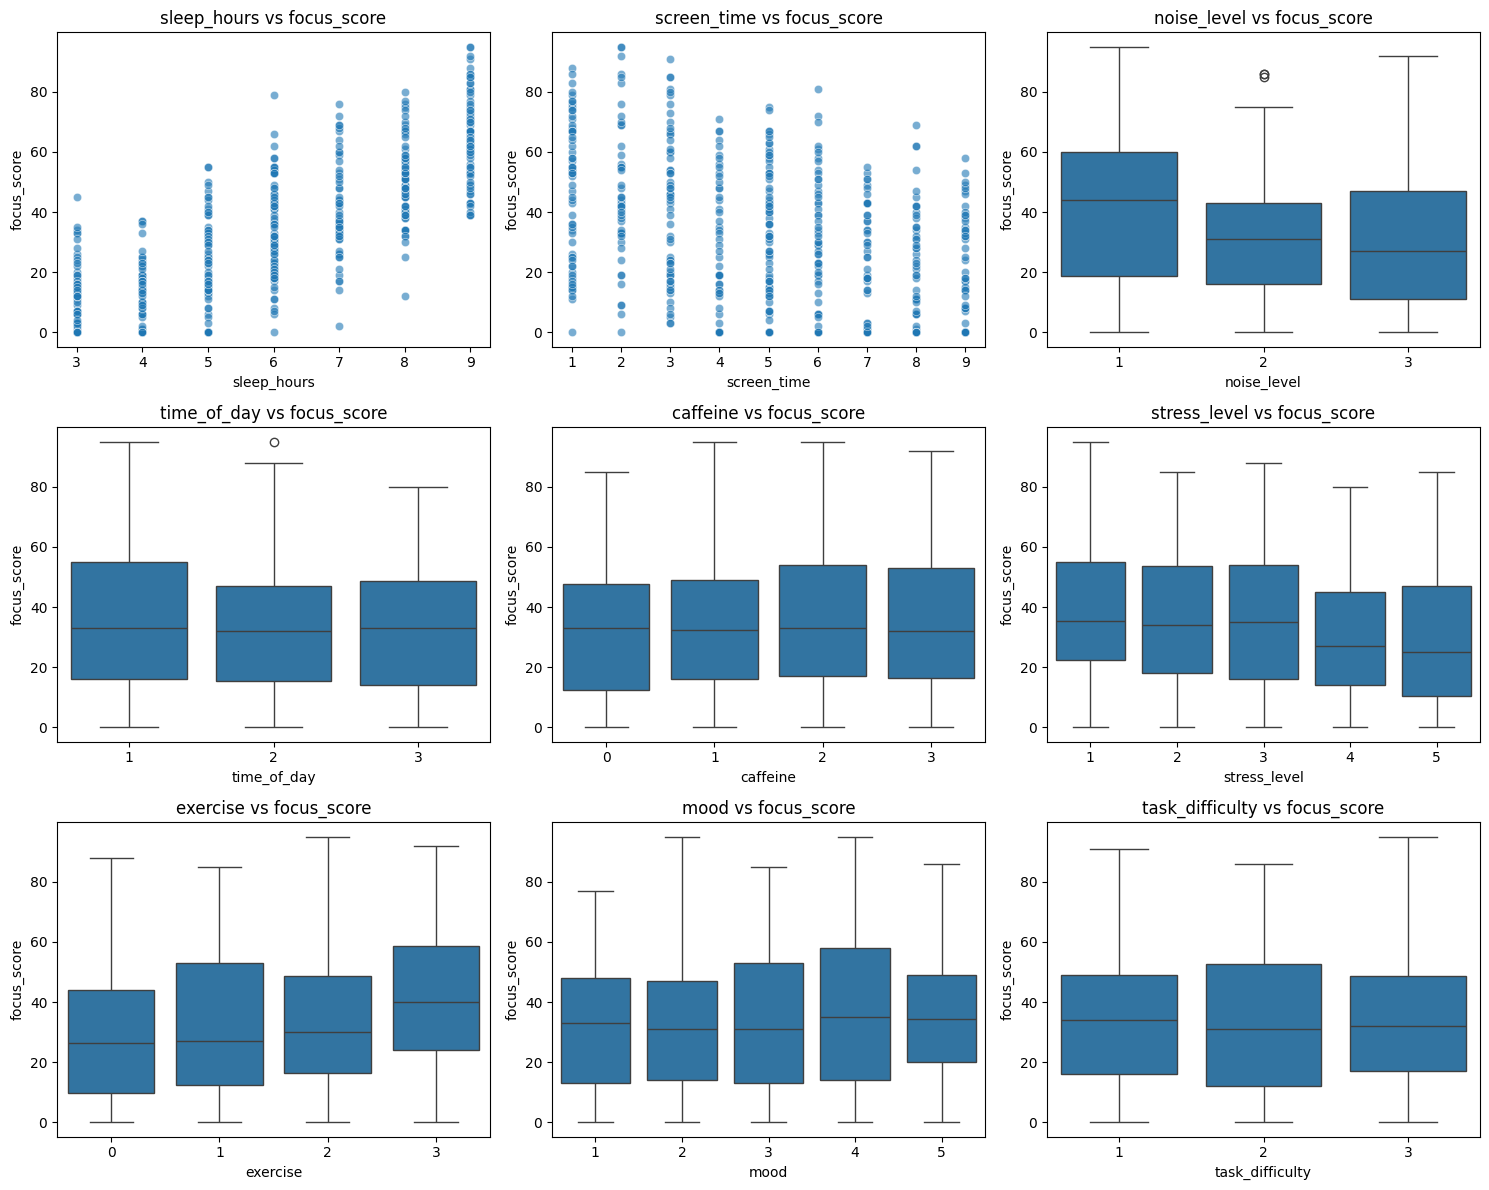

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

target_col = 'focus_score'
feature_cols = [col for col in df.columns if col != target_col]

# Define features that are more categorical/ordinal in nature for box plots
categorical_features = ['noise_level', 'time_of_day', 'caffeine', 'stress_level', 'exercise', 'mood', 'task_difficulty']
continuous_features = [col for col in feature_cols if col not in categorical_features]

# Determine number of rows and columns for subplots
num_features = len(feature_cols)
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, feature in enumerate(feature_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    if feature in continuous_features:
        sns.scatterplot(data=df, x=feature, y=target_col, alpha=0.6)
    else: # Categorical/Ordinal features
        sns.boxplot(data=df, x=feature, y=target_col)
    plt.title(f'{feature} vs {target_col}')
    plt.xlabel(feature)
    plt.ylabel(target_col)

plt.tight_layout()
plt.show()

In [30]:
df_processed = df.copy()

# 1. Convert relevant columns to categorical dtypes
df_processed['noise_level'] = df_processed['noise_level'].astype('category')
df_processed['time_of_day'] = df_processed['time_of_day'].astype('category')

# 2. Bin sleep_hours into sleep_category
def categorize_sleep(hours):
    if hours < 6:
        return 'low_sleep'
    elif 6 <= hours <= 8:
        return 'medium_sleep'
    else:
        return 'high_sleep'

df_processed['sleep_category'] = df_processed['sleep_hours'].apply(categorize_sleep).astype('category')

# 3. Create interaction terms
df_processed['sleep_stress_interaction'] = df_processed['sleep_hours'] * df_processed['stress_level']
df_processed['caffeine_sleep_interaction'] = df_processed['caffeine'] * df_processed['sleep_hours']

# Define columns for one-hot encoding
categorical_cols_for_ohe = ['noise_level', 'time_of_day', 'sleep_category']

# Apply one-hot encoding
X = pd.get_dummies(df_processed.drop('focus_score', axis=1), columns=categorical_cols_for_ohe, drop_first=True)
y = df_processed['focus_score']

print("Feature engineering complete. New DataFrame 'X' created with engineered features.")
print(X.head())

Feature engineering complete. New DataFrame 'X' created with engineered features.
   sleep_hours  screen_time  caffeine  stress_level  exercise  mood  \
0            9            6         1             5         0     3   
1            6            5         3             4         2     5   
2            7            1         1             2         1     4   
3            9            8         0             1         2     1   
4            5            5         1             5         0     5   

   task_difficulty  sleep_stress_interaction  caffeine_sleep_interaction  \
0                1                        45                           9   
1                2                        24                          18   
2                2                        14                           7   
3                2                         9                           0   
4                1                        25                           5   

   noise_level_2  noise_level_3  t

In [31]:
df

,sleep_hours,screen_time,noise_level,time_of_day,caffeine,stress_level,exercise,mood,task_difficulty,focus_score
0,9,6,2,2,1,5,0,3,1,43
1,6,5,3,1,3,4,2,5,2,26
2,7,1,1,1,1,2,1,4,2,60
3,9,8,2,3,0,1,2,1,2,54
4,5,5,1,1,1,5,0,5,1,15
...,...,...,...,...,...,...,...,...,...,...
495,8,9,2,3,3,1,0,4,1,39
496,3,2,1,3,3,2,0,3,3,28
497,6,8,2,2,0,5,0,3,1,7
498,4,8,1,3,0,4,2,5,3,0


In [32]:
df_processed

,sleep_hours,screen_time,noise_level,time_of_day,caffeine,stress_level,exercise,mood,task_difficulty,focus_score,sleep_category,sleep_stress_interaction,caffeine_sleep_interaction
0,9,6,2,2,1,5,0,3,1,43,high_sleep,45,9
1,6,5,3,1,3,4,2,5,2,26,medium_sleep,24,18
2,7,1,1,1,1,2,1,4,2,60,medium_sleep,14,7
3,9,8,2,3,0,1,2,1,2,54,high_sleep,9,0
4,5,5,1,1,1,5,0,5,1,15,low_sleep,25,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,8,9,2,3,3,1,0,4,1,39,medium_sleep,8,24
496,3,2,1,3,3,2,0,3,3,28,low_sleep,6,9
497,6,8,2,2,0,5,0,3,1,7,medium_sleep,30,0
498,4,8,1,3,0,4,2,5,3,0,low_sleep,16,0


In [33]:
from sklearn.preprocessing import LabelEncoder

X_label_encoded = df_processed.copy()

# Define columns to be label encoded
categorical_cols_for_label_encoding = [
    'noise_level',
    'time_of_day',
    'caffeine',
    'stress_level',
    'exercise',
    'mood',
    'task_difficulty',
    'sleep_category'
]

# Initialize a dictionary to store LabelEncoders for each column
label_encoders = {}

# Apply LabelEncoder to each specified column
for col in categorical_cols_for_label_encoding:
    le = LabelEncoder()
    X_label_encoded[col] = le.fit_transform(X_label_encoded[col])
    label_encoders[col] = le # Store the fitted encoder

# Separate features (X) and target (y)
y_label_encoded = X_label_encoded['focus_score']
X_label_encoded = X_label_encoded.drop('focus_score', axis=1)

print("Label encoding complete. New DataFrame 'X_label_encoded' created.")
print(X_label_encoded.head())

Label encoding complete. New DataFrame 'X_label_encoded' created.
   sleep_hours  screen_time  noise_level  time_of_day  caffeine  stress_level  \
0            9            6            1            1         1             4   
1            6            5            2            0         3             3   
2            7            1            0            0         1             1   
3            9            8            1            2         0             0   
4            5            5            0            0         1             4   

   exercise  mood  task_difficulty  sleep_category  sleep_stress_interaction  \
0         0     2                0               0                        45   
1         2     4                1               2                        24   
2         1     3                1               2                        14   
3         2     0                1               0                         9   
4         0     4                0             

### Consistent Train/Test Split for All Models

In [34]:
from sklearn.model_selection import train_test_split

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_label_encoded, y_label_encoded, test_size=0.2, random_state=42
)

print("Consistent train/test split created.")
print(f"X_train_split shape: {X_train_split.shape}")
print(f"X_test_split shape: {X_test_split.shape}")
print(f"y_train_split shape: {y_train_split.shape}")
print(f"y_test_split shape: {y_test_split.shape}")

Consistent train/test split created.
X_train_split shape: (400, 12)
X_test_split shape: (100, 12)
y_train_split shape: (400,)
y_test_split shape: (100,)


### 1. Evaluate Linear Regression on Consistent Split

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Linear Regression model
lr_model_split = LinearRegression()
lr_model_split.fit(X_train_split, y_train_split)

# Make predictions
y_pred_lr_split = lr_model_split.predict(X_test_split)

# Evaluate the model
mse_lr_split = mean_squared_error(y_test_split, y_pred_lr_split)
rmse_lr_split = np.sqrt(mse_lr_split)
mae_lr_split = mean_absolute_error(y_test_split, y_pred_lr_split)
r2_lr_split = r2_score(y_test_split, y_pred_lr_split)

print("Linear Regression Performance on Consistent Test Split:")
print(f"RMSE: {rmse_lr_split:.4f}")
print(f"MAE: {mae_lr_split:.4f}")
print(f"R2 Score: {r2_lr_split:.4f}")

Linear Regression Performance on Consistent Test Split:
RMSE: 6.2631
MAE: 5.3205
R2 Score: 0.9210


### 2. Evaluate Random Forest on Consistent Split

In [36]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest model
rf_model_split = RandomForestRegressor(random_state=42)
rf_model_split.fit(X_train_split, y_train_split)

# Make predictions
y_pred_rf_split = rf_model_split.predict(X_test_split)

# Evaluate the model
mse_rf_split = mean_squared_error(y_test_split, y_pred_rf_split)
rmse_rf_split = np.sqrt(mse_rf_split)
mae_rf_split = mean_absolute_error(y_test_split, y_pred_rf_split)
r2_rf_split = r2_score(y_test_split, y_pred_rf_split)

print("Random Forest Performance on Consistent Test Split:")
print(f"RMSE: {rmse_rf_split:.4f}")
print(f"MAE: {mae_rf_split:.4f}")
print(f"R2 Score: {r2_rf_split:.4f}")

Random Forest Performance on Consistent Test Split:
RMSE: 7.0997
MAE: 5.9559
R2 Score: 0.8985


### 3. Evaluate XGBoost (Best Tuned) on Consistent Split

In [37]:
from xgboost import XGBRegressor

# Use tuned params when available; otherwise fall back to defaults.
if "best_params" in globals():
    xgb_params_to_use = best_params
    print("Using tuned XGBoost hyperparameters from RandomizedSearchCV.")
else:
    xgb_params_to_use = {}
    print("best_params not found yet; using default XGBoost hyperparameters.")

best_xgb_model_split = XGBRegressor(random_state=42, **xgb_params_to_use)
best_xgb_model_split.fit(X_train_split, y_train_split)

# Make predictions
y_pred_xgb_split = best_xgb_model_split.predict(X_test_split)

# Evaluate the model
mse_xgb_split = mean_squared_error(y_test_split, y_pred_xgb_split)
rmse_xgb_split = np.sqrt(mse_xgb_split)
mae_xgb_split = mean_absolute_error(y_test_split, y_pred_xgb_split)
r2_xgb_split = r2_score(y_test_split, y_pred_xgb_split)

print("XGBoost Performance on Consistent Test Split:")
print(f"RMSE: {rmse_xgb_split:.4f}")
print(f"MAE: {mae_xgb_split:.4f}")
print(f"R2 Score: {r2_xgb_split:.4f}")

Using tuned XGBoost hyperparameters from RandomizedSearchCV.
XGBoost Performance on Consistent Test Split:
RMSE: 6.3612
MAE: 5.2566
R2 Score: 0.9185


### Summary of Model Performance on Consistent Test Split

In [38]:
print("\n--- Model Performance Comparison (Consistent Test Split) ---")
print(f"Linear Regression - RMSE: {rmse_lr_split:.4f}, MAE: {mae_lr_split:.4f}, R2: {r2_lr_split:.4f}")
print(f"Random Forest     - RMSE: {rmse_rf_split:.4f}, MAE: {mae_rf_split:.4f}, R2: {r2_rf_split:.4f}")
print(f"XGBoost (Tuned)   - RMSE: {rmse_xgb_split:.4f}, MAE: {mae_xgb_split:.4f}, R2: {r2_xgb_split:.4f}")


--- Model Performance Comparison (Consistent Test Split) ---
Linear Regression - RMSE: 6.2631, MAE: 5.3205, R2: 0.9210
Random Forest     - RMSE: 7.0997, MAE: 5.9559, R2: 0.8985
XGBoost (Tuned)   - RMSE: 6.3612, MAE: 5.2566, R2: 0.9185


In [39]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np

# Define the XGBoost Regressor model
xgb = XGBRegressor(random_state=42)

# Ensure hyperparameter search space exists even if cells run out of order.
if 'param_dist' not in globals():
    param_dist = {
        'n_estimators': [100, 200, 300, 500],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 4, 5, 6, 8],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'gamma': [0, 0.1, 0.2, 0.3],
        'reg_alpha': [0, 0.01, 0.1, 1],
        'reg_lambda': [1, 1.5, 2, 3]
    }

# Perform Randomized Search Cross-Validation
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=100, # Number of parameter settings that are sampled
    scoring='neg_mean_squared_error', # Use negative MSE to maximize (equivalent to minimizing MSE)
    cv=5, # 5-fold cross-validation
    verbose=1, # Display progress
    random_state=42,
    n_jobs=-1 # Use all available cores
)

random_search.fit(X_label_encoded, y_label_encoded)

# Get the best parameters and best score
best_params = random_search.best_params_
best_rmse = np.sqrt(-random_search.best_score_)

print("Best Hyperparameters:", best_params)
print(f"Best RMSE: {best_rmse:.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Hyperparameters: {'subsample': 0.7, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}
Best RMSE: 6.1686


In [40]:
# Hyperparameter search space for XGBoost tuning
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 1.5, 2, 3]
}

param_dist

{'n_estimators': [100, 200, 300, 500],
 'learning_rate': [0.01, 0.05, 0.1, 0.2],
 'max_depth': [3, 4, 5, 6, 8],
 'subsample': [0.7, 0.8, 0.9, 1.0],
 'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
 'gamma': [0, 0.1, 0.2, 0.3],
 'reg_alpha': [0, 0.01, 0.1, 1],
 'reg_lambda': [1, 1.5, 2, 3]}

In [41]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Train the XGBoost model with the best hyperparameters
best_xgb_model = XGBRegressor(random_state=42, **best_params)
best_xgb_model.fit(X_label_encoded, y_label_encoded)

# Make predictions on the entire dataset
y_pred_best_xgb = best_xgb_model.predict(X_label_encoded)

# Evaluate the predictions
mse_best = mean_squared_error(y_label_encoded, y_pred_best_xgb)
rmse_best = np.sqrt(mse_best)
mae_best = mean_absolute_error(y_label_encoded, y_pred_best_xgb)

print("First 5 predictions from the best XGBoost model:")
print(y_pred_best_xgb[:5])
print(f"\nRMSE on the entire dataset (best XGBoost): {rmse_best:.4f}")
print(f"MAE on the entire dataset (best XGBoost): {mae_best:.4f}")

First 5 predictions from the best XGBoost model:
[45.016853 30.983858 68.36034  51.106976 18.019272]

RMSE on the entire dataset (best XGBoost): 4.2375
MAE on the entire dataset (best XGBoost): 3.4915


In [42]:
from sklearn.model_selection import KFold, cross_val_score

# Define the cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(
    best_xgb_model, # Use the best trained XGBoost model
    X_label_encoded,
    y_label_encoded,
    cv=kf,
    scoring='neg_mean_squared_error', # Use negative MSE to maximize (minimize MSE)
    n_jobs=-1 # Use all available cores
)

# Convert negative MSE scores to positive RMSE scores
cv_rmse_scores = np.sqrt(-cv_scores)

print(f"Cross-Validation RMSE Scores: {cv_rmse_scores}")
print(f"Mean Cross-Validation RMSE: {cv_rmse_scores.mean():.4f}")
print(f"Standard Deviation of Cross-Validation RMSE: {cv_rmse_scores.std():.4f}")

Cross-Validation RMSE Scores: [6.05249961 6.17360831 5.71174074 6.82431421 5.97345998]
Mean Cross-Validation RMSE: 6.1471
Standard Deviation of Cross-Validation RMSE: 0.3709


Feature Importances for the Best XGBoost Model:
                       Feature  Importance
0                  sleep_hours    0.470259
9               sleep_category    0.149376
1                  screen_time    0.120301
2                  noise_level    0.054647
6                     exercise    0.049171
11  caffeine_sleep_interaction    0.044677
5                 stress_level    0.034407
10    sleep_stress_interaction    0.021712
7                         mood    0.019518
4                     caffeine    0.014669
8              task_difficulty    0.014443
3                  time_of_day    0.006820


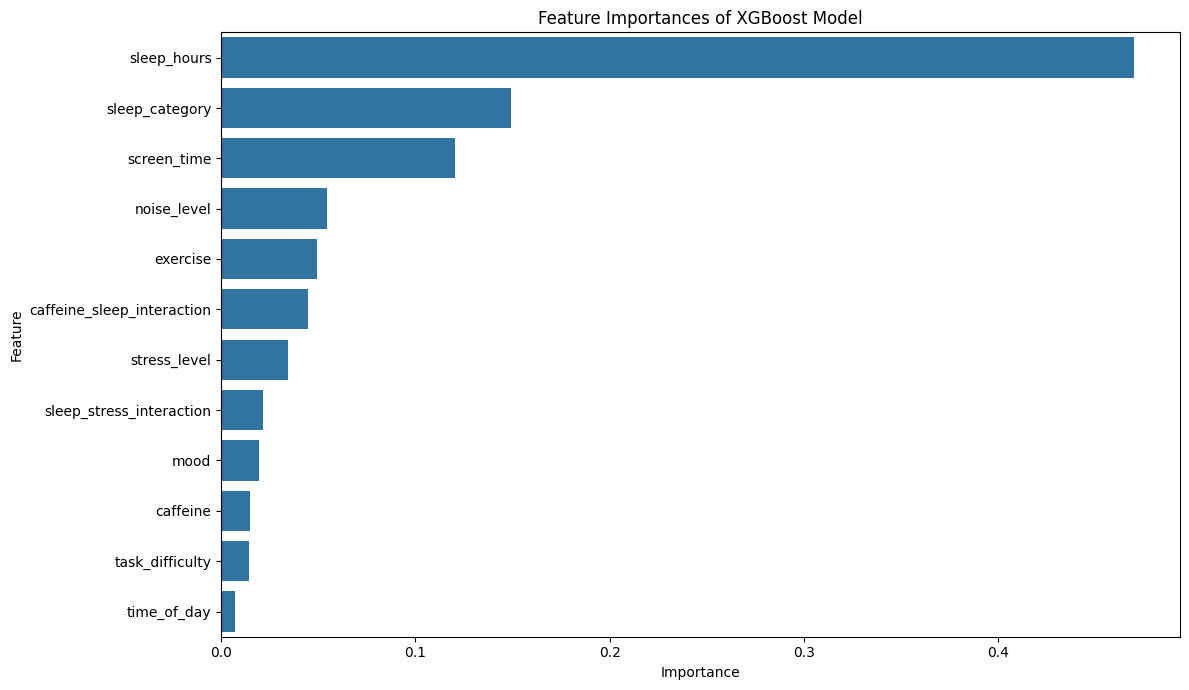

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best XGBoost model
importances = best_xgb_model.feature_importances_

# Get feature names from the processed DataFrame
feature_names = X_label_encoded.columns

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the sorted feature importances
print("Feature Importances for the Best XGBoost Model:")
print(feature_importance_df)

# Plot the feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances of XGBoost Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Predicting Focus Score for New Input

To make a prediction with our trained `best_xgb_model`, any new input data must be preprocessed in the same way as the training data. This involves:
1.  Creating a Pandas DataFrame from the raw input.
2.  Converting relevant columns to categorical types.
3.  Binning `sleep_hours` into `sleep_category`.
4.  Creating interaction terms (`sleep_stress_interaction`, `caffeine_sleep_interaction`).
5.  Applying Label Encoding using the same `LabelEncoder` instance (`le`) that was fitted on the training data (`X_label_encoded`).

Let's demonstrate this with a sample new input.

In [44]:
import pandas as pd

# Sample new input data (as a dictionary)
new_input_data = {
    'sleep_hours': [8],
    'screen_time': [9],
    'noise_level': [2],
    'time_of_day': [1],
    'caffeine': [2],
    'stress_level': [3],
    'exercise': [2],
    'mood': [4],
    'task_difficulty': [2]
}

# Define a helper function to preprocess and predict for a single input
def predict_focus_for_input(input_dict, model, X_cols, cat_cols_for_le, label_encoders_dict, sleep_categorizer):
    X_single_raw = pd.DataFrame(input_dict)

    # Apply the same preprocessing steps as df_processed:
    X_single_raw['noise_level'] = X_single_raw['noise_level'].astype('category')
    X_single_raw['time_of_day'] = X_single_raw['time_of_day'].astype('category')
    X_single_raw['sleep_category'] = X_single_raw['sleep_hours'].apply(sleep_categorizer).astype('category')
    X_single_raw['sleep_stress_interaction'] = X_single_raw['sleep_hours'] * X_single_raw['stress_level']
    X_single_raw['caffeine_sleep_interaction'] = X_single_raw['caffeine'] * X_single_raw['sleep_hours']

    X_single_processed = X_single_raw.copy()

    # Apply LabelEncoder using the already fitted `label_encoders_dict` from training
    for col in cat_cols_for_le:
        if col in label_encoders_dict:
            try:
                X_single_processed[col] = label_encoders_dict[col].transform(X_single_processed[col])
            except ValueError as e:
                print(f"Error transforming column {col}: {e}. Ensure all categories were seen during training.")
                return None # Or handle the error as appropriate
        else:
            print(f"Warning: LabelEncoder for column {col} not found in the dictionary. Skipping transformation.")

    # Ensure column order matches X_label_encoded if not all features were present in input_dict
    final_X_single = pd.DataFrame(columns=X_cols)
    for col in X_cols:
        if col in X_single_processed.columns:
            final_X_single[col] = X_single_processed[col]
        else:
            final_X_single[col] = 0 # Fill missing (e.g., OHE columns that didn't apply) with 0

    final_X_single = final_X_single.astype(dict(zip(X_cols, X_label_encoded.dtypes))) # Match dtypes

    return model.predict(final_X_single)[0]

# Get the initial predicted focus score for the new input
initial_predicted_focus = predict_focus_for_input(
    new_input_data,
    best_xgb_model,
    X_label_encoded.columns,
    categorical_cols_for_label_encoding,
    label_encoders, # Use the dictionary of label encoders
    categorize_sleep
)

if initial_predicted_focus is not None:
    print(f"Predicted Focus Score for the new input: {initial_predicted_focus:.2f}")
    print("\n--- Suggestions for Improvement ---")

    suggestions = []

    # Suggestion 1: Increase sleep hours (from 8 to 9)
    improved_sleep_data = new_input_data.copy()
    improved_sleep_data['sleep_hours'] = [9]
    predicted_focus_sleep = predict_focus_for_input(
        improved_sleep_data,
        best_xgb_model,
        X_label_encoded.columns,
        categorical_cols_for_label_encoding,
        label_encoders,
        categorize_sleep
    )
    if predicted_focus_sleep is not None and predicted_focus_sleep > initial_predicted_focus:
        suggestions.append(f"- Try to increase sleep hours to 9 hours. This could boost your focus score to {predicted_focus_sleep:.2f}.")

    # Suggestion 2: Decrease screen time (from 9 to 6)
    reduced_screen_data = new_input_data.copy()
    reduced_screen_data['screen_time'] = [6]
    predicted_focus_screen = predict_focus_for_input(
        reduced_screen_data,
        best_xgb_model,
        X_label_encoded.columns,
        categorical_cols_for_label_encoding,
        label_encoders,
        categorize_sleep
    )
    if predicted_focus_screen is not None and predicted_focus_screen > initial_predicted_focus:
        suggestions.append(f"- Reduce your screen time to 6 hours. This might increase your focus score to {predicted_focus_screen:.2f}.")

    # Suggestion 3: Decrease stress level (from 3 to 1)
    reduced_stress_data = new_input_data.copy()
    reduced_stress_data['stress_level'] = [1]
    predicted_focus_stress = predict_focus_for_input(
        reduced_stress_data,
        best_xgb_model,
        X_label_encoded.columns,
        categorical_cols_for_label_encoding,
        label_encoders,
        categorize_sleep
    )
    if predicted_focus_stress is not None and predicted_focus_stress > initial_predicted_focus:
        suggestions.append(f"- Work on reducing your stress level to 1 (low). This could raise your focus score to {predicted_focus_stress:.2f}.")

    # Suggestion 4: Increase exercise (from 2 to 3)
    increased_exercise_data = new_input_data.copy()
    increased_exercise_data['exercise'] = [3]
    predicted_focus_exercise = predict_focus_for_input(
        increased_exercise_data,
        best_xgb_model,
        X_label_encoded.columns,
        categorical_cols_for_label_encoding,
        label_encoders,
        categorize_sleep
    )
    if predicted_focus_exercise is not None and predicted_focus_exercise > initial_predicted_focus:
        suggestions.append(f"- Consider increasing your exercise frequency/intensity to 3. This may improve your focus score to {predicted_focus_exercise:.2f}.")

    if suggestions:
        for suggestion in suggestions:
            print(suggestion)
    else:
        print("No immediate single-factor improvements significantly increased the focus score based on tested parameters. Consider combinations or other factors.")
else:
    print("Could not generate suggestions due to prediction error.")

Predicted Focus Score for the new input: 41.95

--- Suggestions for Improvement ---
- Try to increase sleep hours to 9 hours. This could boost your focus score to 54.76.
- Reduce your screen time to 6 hours. This might increase your focus score to 54.01.
- Work on reducing your stress level to 1 (low). This could raise your focus score to 44.93.
- Consider increasing your exercise frequency/intensity to 3. This may improve your focus score to 43.14.
